ASSIGNMENT 4 : Write a program to implement the naïve Bayesian classifier for a sample training data set stored as a .CSV file. Compute the accuracy of the classifier, considering few test data sets.



Multinomial Naïve Bayes Result
Accuracy: 0.7723880597014925

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       165
           1       0.71      0.70      0.70       103

    accuracy                           0.77       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268



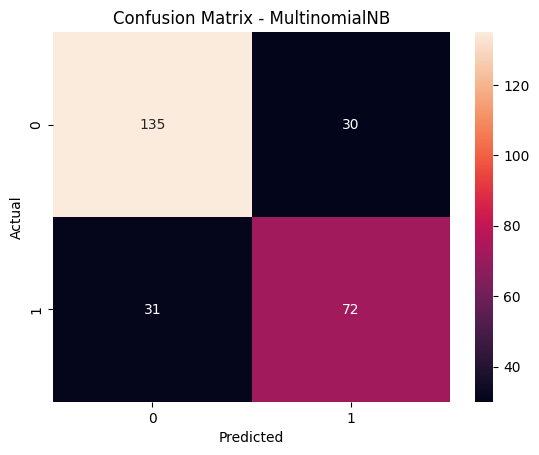

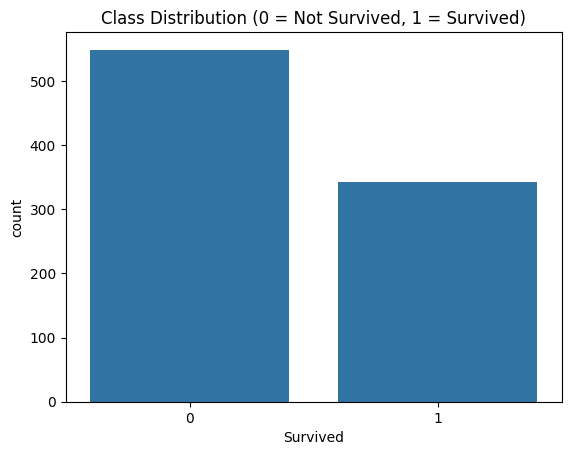

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("titanic.csv")

data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Fare'] = data['Fare'].fillna(data['Fare'].mean())

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})



data['Age'] = pd.cut(data['Age'], bins=4, labels=False)


data['Fare'] = pd.cut(data['Fare'], bins=4, labels=False)

X = data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = data['Survived']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


model = MultinomialNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)


print("Multinomial Naïve Bayes Result")

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - MultinomialNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




plt.figure()
sns.countplot(x='Survived', data=data)
plt.title("Class Distribution (0 = Not Survived, 1 = Survived)")
plt.show()



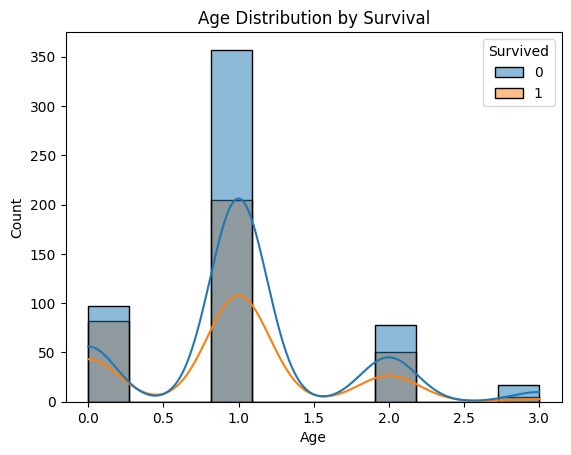

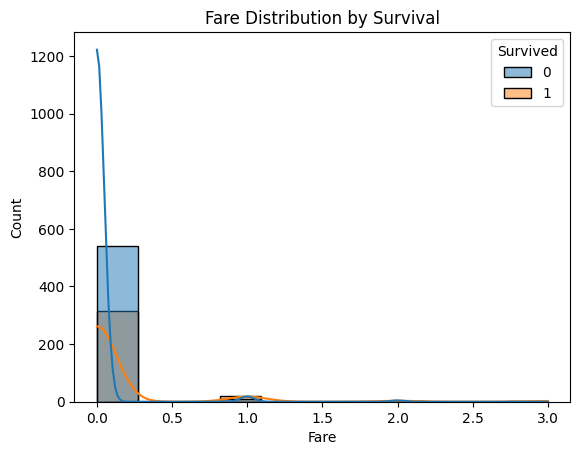


Manual Test Prediction: Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


In [ ]:
plt.figure()
sns.histplot(data=data, x='Age', hue='Survived', kde=True)
plt.title("Age Distribution by Survival")
plt.show()

plt.figure()
sns.histplot(data=data, x='Fare', hue='Survived', kde=True)
plt.title("Fare Distribution by Survival")
plt.show()



sample_data = np.array([[3, 0, 25, 0, 0, 7.25]])
prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("\nManual Test Prediction: Survived")
else:
    print("\nManual Test Prediction: Not Survived")
